In [3]:
import pandas as pd
import json
import numpy as np

from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef, confusion_matrix, precision_recall_curve

from xgboost import XGBClassifier
import xgboost as xgb
import lightgbm as lgb
from imblearn.ensemble import BalancedRandomForestClassifier

# import packages for hyperparameters tuning
import optuna

import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')

/shared/nas2/anna19/miniconda3/envs/class_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1777911794.456298 1274922 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
model_for_testing = 'foldseek3di'  # 'protTrans' | 'esm' | 'foldseek3di'

if model_for_testing == 'foldseek3di':
    df = pd.read_csv('/shared/nas2/anna19/class_project/uniprot_dataset/3di_tokens/uniprot_dataset_foldseek3di.csv')
    label_col   = 'label'
    residue_col = 'residue_letter'
else:
    df = pd.read_csv('/home/dimitra/master_thesis/Datasets/My_Dataset/proteins_embeddings_' + model_for_testing + '_annotated.csv', index_col=0)
    label_col   = 'is_IBS'
    residue_col = 'residue_1l'

# one-hot encode amino acid residues
df_res = pd.get_dummies(df[residue_col], prefix='aa').astype(int)
df = df.merge(df_res, left_index=True, right_index=True, how='inner')

# one-hot encode 3Di tokens (only for foldseek3di; AA and 3Di alphabets are identical so prefixes are required)
if model_for_testing == 'foldseek3di':
    df_3di = pd.get_dummies(df['3di_token'], prefix='3di').astype(int)
    df = df.merge(df_3di, left_index=True, right_index=True, how='inner')

df.insert(len(df.columns)-1, label_col, df.pop(label_col))
print(df.shape)

f = open('/shared/nas2/anna19/class_project/pLM-PMI-main/Datasets/Uniprot_dataset/split_proteins.json')
dict_proteins_split = json.load(f)
f.close()

df_train = df[df.uniprot_id.isin(dict_proteins_split['train'])]
df_test  = df[df.uniprot_id.isin(dict_proteins_split['test'])]
df_val   = df[df.uniprot_id.isin(dict_proteins_split['val'])]

positive_samples = df_train[label_col].astype(int).sum()
negative_samples = len(df_train) - positive_samples
ratio = negative_samples / positive_samples

drop_cols = [c for c in ['uniprot_id', residue_col, 'residue_number', '3di_token', label_col]
             if c in df.columns]

X_train, y_train = df_train.drop(drop_cols, axis=1), df_train[label_col].astype(int)
X_test,  y_test  = df_test.drop(drop_cols, axis=1),  df_test[label_col].astype(int)
X_val,   y_val   = df_val.drop(drop_cols, axis=1),   df_val[label_col].astype(int)

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)
import gc

del df, df_train, df_test, df_val, df_res
gc.collect()

X_train, y_train = X_train.values, y_train.values
X_test,  y_test  = X_test.values,  y_test.values

(312777, 1069)
(284129, 1064)
(7776, 1064)
(5967, 1064)


### Optimize LGBM


In [3]:
# define the params and the metric function
def objective(trial):
  params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'metric': 'binary_logloss',
    'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
    "max_depth": trial.suggest_int("max_depth", 1, 31, step=2),
    "scale_pos_weight": trial.suggest_float("scale_pos_weight", ratio-5, ratio+5),
    'num_leaves': trial.suggest_int('num_leaves', 20, 100),
    'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
    'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
    'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
    'lambda_l1': trial.suggest_float('lambda_l1', 0, 1),
    'lambda_l2': trial.suggest_float('lambda_l2', 0, 1),
    "num_iterations": trial.suggest_int("num_iterations", 100, 2000, step=100),
    'verbosity': -1,
    'device_type': 'cpu',
    'random_state': 42,
    'n_jobs': -1
}
  model = lgb.train(params, lgb.Dataset(X_train, y_train))

  preds = model.predict(X_val)
  pred_labels = np.rint(preds)

  f1 =  f1_score(y_val, pred_labels)

  return f1

# start fine-tuning and search for the optimal hyper-params
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2024-03-28 16:23:59,494] A new study created in memory with name: no-name-4437b2ff-7f48-4af3-8409-bcd6a9e3c865
[I 2024-03-28 16:27:24,981] Trial 0 finished with value: 0.5361952861952861 and parameters: {'learning_rate': 0.006074219550826093, 'max_depth': 9, 'scale_pos_weight': 32.14284292231546, 'num_leaves': 36, 'feature_fraction': 0.860681142606906, 'bagging_fraction': 0.7712060811379233, 'bagging_freq': 8, 'lambda_l1': 0.62956544175204, 'lambda_l2': 0.03631846152524043, 'num_iterations': 1800}. Best is trial 0 with value: 0.5361952861952861.
[I 2024-03-28 16:28:12,767] Trial 1 finished with value: 0.4588715159755269 and parameters: {'learning_rate': 0.010995749081307779, 'max_depth': 3, 'scale_pos_weight': 35.05340905931346, 'num_leaves': 36, 'feature_fraction': 0.856104424936892, 'bagging_fraction': 0.9700474987709665, 'bagging_freq': 4, 'lambda_l1': 0.35422701611246976, 'lambda_l2': 0.3026931698249439, 'num_iterations': 1500}. Best is trial 0 with value: 0.5361952861952861.
[I

Number of finished trials:  200
Best trial:
  Value: 0.6333113890717578
  Params: 
    learning_rate: 0.01380605288076058
    max_depth: 31
    scale_pos_weight: 34.683464805409834
    num_leaves: 84
    feature_fraction: 0.7271452869823677
    bagging_fraction: 0.755295392779871
    bagging_freq: 7
    lambda_l1: 0.35802780689923713
    lambda_l2: 0.8098299642862663
    num_iterations: 2000


In [5]:
clf = lgb.LGBMClassifier(device_type= 'cpu',
    verbosity= -1,
    random_state= 42,
    n_jobs= -1, 
    # **params
    **study.best_trial.params
    )

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print()
print("----------- Model ---------")
print(model_for_testing)
print()
print('F1 score: %.3f ' % f1_score(y_test, y_pred))
print('MCC: %.3f ' % matthews_corrcoef(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
cm = pd.DataFrame(cm , index = ['0','1'] , columns = ['0','1'])
print(cm)


----------- Model ---------
protTrans

F1 score: 0.674 
MCC: 0.634 
      0    1
0  6637  275
1   285  579


### Optimize XGBoost

In [15]:
xgb_clf = XGBClassifier()

dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_val, label=y_val)

trials = {}
# 1. Define an objective function to be maximized.
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        "booster": trial.suggest_categorical("booster", ["gbtree", "dart"]),
        "gamma": trial.suggest_float("gamma", 0.7, 1.0, step=0.1),
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "max_depth": trial.suggest_int("max_depth", 1, 31, step=2),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", ratio-5, ratio+5),
    }

    bst = xgb.train(param, dtrain)
    preds = bst.predict(dvalid)
    pred_labels = np.rint(preds)

    f1 =  f1_score(y_val, pred_labels)
    mcc =  matthews_corrcoef(y_val, pred_labels)
    conf_matrix = confusion_matrix(y_val, pred_labels)

    trials[trial.number] = [f1, mcc, conf_matrix]    
    return f1

# 3. Create a study object and optimize the objective function.
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

[I 2024-01-23 13:26:53,408] A new study created in memory with name: no-name-c84a1349-96ae-4551-861d-273f68315eef
[I 2024-01-23 13:27:18,379] Trial 0 finished with value: 0.4389920424403183 and parameters: {'learning_rate': 0.0012641991782402873, 'booster': 'gbtree', 'gamma': 1.0, 'lambda': 1.1668214802791591e-05, 'reg_alpha': 2.280211019758367, 'subsample': 0.8843771568323349, 'colsample_bytree': 0.7232707745585862, 'max_depth': 13, 'min_child_weight': 6, 'scale_pos_weight': 36.41220956670108}. Best is trial 0 with value: 0.4389920424403183.
[I 2024-01-23 13:27:50,182] Trial 1 finished with value: 0.30665380906460943 and parameters: {'learning_rate': 0.003098403261906665, 'booster': 'dart', 'gamma': 1.0, 'lambda': 3.0372221662472634e-06, 'reg_alpha': 5.038250753174373, 'subsample': 0.5362969263049406, 'colsample_bytree': 0.864917218190785, 'max_depth': 31, 'min_child_weight': 5, 'scale_pos_weight': 31.435649442807488}. Best is trial 0 with value: 0.4389920424403183.
[I 2024-01-23 13:2

In [16]:
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

Number of finished trials:  200
Best trial:
  Value: 0.5014343086632244
  Params: 
    learning_rate: 0.018532546571990664
    booster: gbtree
    gamma: 0.7999999999999999
    lambda: 0.00010690298719347456
    reg_alpha: 9.353729121385786
    subsample: 0.6835366299983335
    colsample_bytree: 0.7145795902754652
    max_depth: 11
    min_child_weight: 4
    scale_pos_weight: 38.948239592913026


In [19]:
xgb_clf = XGBClassifier(objective='binary:logistic', **trial.params, n_jobs=-1, random_state=42)

xgb_clf.fit(X_train, y_train)

# evaluate model on the traindataset
ypred = xgb_clf.predict(X_test)

print('F1 score: %.3f ' % f1_score(y_test, ypred))
print('MCC: %.3f ' % matthews_corrcoef(y_test, ypred))

cm = confusion_matrix(y_test, ypred)
cm = pd.DataFrame(cm , index = ['0','1'] , columns = ['0','1'])
print(cm)

F1 score: 0.581 
MCC: 0.526 
      0    1
0  6450  462
1   321  543


### Optimize BalancedRandomForest

In [1]:
import sklearn.model_selection

trials = {}
# 1. Define an objective function to be maximized.
def objective(trial):
    params_brf = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "max_depth": trial.suggest_int("max_depth", 1, 31, step=2),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_float("max_features", 0.1, 1.0, log=True),
    }

    brf = BalancedRandomForestClassifier(replacement=True, sampling_strategy= "all", **params_brf, n_jobs=-1)
    score = sklearn.model_selection.cross_val_score(brf, X_train, y_train, scoring="f1", n_jobs=-1, cv=3).mean()

    return score

# 3. Create a study object and optimize the objective function.
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

KeyboardInterrupt: 

In [4]:
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

Number of finished trials:  200
Best trial:
  Value: 0.37151608632333377
  Params: 
    n_estimators: 365
    criterion: gini
    max_depth: 31
    min_samples_split: 3
    min_samples_leaf: 2
    max_features: 0.10008218569519407


In [5]:
trial = study.best_trial
brf_clf = BalancedRandomForestClassifier(replacement=True, sampling_strategy= "all", n_jobs=-1, **trial.params)
brf_clf.fit(X_train, y_train)
ypred = brf_clf.predict(X_test)

print('F1 score: %.3f ' % f1_score(y_test, ypred))
print('MCC: %.3f ' % matthews_corrcoef(y_test, ypred))
print('Balanced accuracy: %.3f ' % balanced_accuracy_score(y_test, ypred))

cm = confusion_matrix(y_test, ypred)
cm = pd.DataFrame(cm , index = ['0','1'] , columns = ['0','1'])
print(cm)

F1 score: 0.525 
MCC: 0.465 
Balanced accuracy: 0.779 
      0    1
0  6150  762
1   286  578


### Optimize SLP

In [5]:
def objective(trial):
    # Define hyperparameters to be optimized
    params = {
        'hidden_layer_sizes': trial.suggest_int('hidden_layer_sizes', 1, 1000),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'sigmoid']),
        'optimizer': trial.suggest_categorical('optimizer', ['adam', 'sgd']),
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True),
        'epochs': 20,
    }

    # Build the MLP model with the suggested hyperparameters
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(units=params['hidden_layer_sizes'], activation=params['activation'], input_dim=X_train.shape[1]))
    model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))  # Assuming binary classification

    # Compile the model
    if params['optimizer'] == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=params['learning_rate'])

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model on the training set
    model.fit(X_train, y_train, epochs=params['epochs'], verbose=0)

    # Make predictions on the validation set
    y_pred_proba = model.predict(X_val)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Calculate accuracy on the validation set
    f1 = f1_score(y_val, y_pred)

    return f1  # Optimize for accuracy, so minimize the error

# Create an Optuna study
study = optuna.create_study(direction='maximize')

# Optimize the objective function
study.optimize(objective, n_trials=50)

# Get the best hyperparameters
best_params = study.best_params
print("Best hyperparameters:", best_params)

[I 2026-05-04 11:25:31,498] A new study created in memory with name: no-name-0ac1736e-aa55-42c3-9553-3a449a87854c
W0000 00:00:1777911931.720291 1274922 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


[I 2026-05-04 11:31:43,963] Trial 0 finished with value: 0.5632958801498127 and parameters: {'hidden_layer_sizes': 3, 'activation': 'sigmoid', 'optimizer': 'sgd', 'learning_rate': 0.03287570782579461}. Best is trial 0 with value: 0.5632958801498127.


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


[I 2026-05-04 11:42:05,957] Trial 1 finished with value: 0.5017985611510791 and parameters: {'hidden_layer_sizes': 385, 'activation': 'relu', 'optimizer': 'sgd', 'learning_rate': 0.002947587764769904}. Best is trial 0 with value: 0.5632958801498127.


...

187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


[I 2026-05-04 21:53:17,860] Trial 48 finished with value: 0.0 and parameters: {'hidden_layer_sizes': 566, 'activation': 'relu', 'optimizer': 'sgd', 'learning_rate': 3.719892253236579e-05}. Best is trial 42 with value: 0.6589041095890411.


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


[I 2026-05-04 22:05:53,862] Trial 49 finished with value: 0.6324054246966453 and parameters: {'hidden_layer_sizes': 745, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 1.1210448341780552e-05}. Best is trial 42 with value: 0.6589041095890411.


Best hyperparameters: {'hidden_layer_sizes': 414, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.00012674933671911033}


In [6]:
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

Number of finished trials:  50
Best trial:
  Value: 0.6589041095890411
  Params: 
    hidden_layer_sizes: 414
    activation: relu
    optimizer: adam
    learning_rate: 0.00012674933671911033


In [7]:
#  Trial 2 finished with value: 0.5825958702064896 and parameters: {'hidden_layer_sizes': 412, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.00040448886589716375}. Best is trial 1 with value: 0.005256241787122207.
metrics = [
  tf.keras.metrics.TruePositives(name='tp'),
  tf.keras.metrics.FalsePositives(name='fp'),
  tf.keras.metrics.TrueNegatives(name='tn'),
  tf.keras.metrics.FalseNegatives(name='fn'), 
  tf.keras.metrics.Precision(name='precision'),
  tf.keras.metrics.Recall(name='recall'),
]

# Build the final model with the best hyperparameters on the entire training set
final_model = tf.keras.models.Sequential()
final_model.add(tf.keras.layers.Dense(units=776, activation='relu', input_dim=X_train.shape[1]))
final_model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))  # Assuming binary classification

# Compile the final model
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0009146523695170536), loss='binary_crossentropy', metrics=metrics)

# Train the final model on the entire training set
final_model.fit(X_train, y_train, epochs=20)

ypred = final_model.predict(X_test)

print('F1 score: %.3f ' % f1_score(y_test, ypred > 0.5))
print('MCC: %.3f ' % matthews_corrcoef(y_test, ypred > 0.5))

cm = confusion_matrix(y_test, ypred > 0.5)
cm = pd.DataFrame(cm , index = ['0','1'] , columns = ['0','1'])
print(cm)

Epoch 1/20
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 44s 5ms/step - fn: 4138.0000 - fp: 1551.0000 - loss: 0.0537 - precision: 0.7269 - recall: 0.4994 - tn: 274312.0000 - tp: 4128.0000
Epoch 2/20
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - fn: 2606.0000 - fp: 1589.0000 - loss: 0.0364 - precision: 0.7808 - recall: 0.6847 - tn: 274274.0000 - tp: 5660.0000
Epoch 3/20
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - fn: 1838.0000 - fp: 1306.0000 - loss: 0.0275 - precision: 0.8311 - recall: 0.7776 - tn: 274557.0000 - tp: 6428.0000
Epoch 4/20
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - fn: 1311.0000 - fp: 1070.0000 - loss: 0.0212 - precision: 0.8667 - recall: 0.8414 - tn: 274793.0000 - tp: 6955.0000
Epoch 5/20
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - fn: 954.0000 - fp: 805.0000 - loss: 0.0164 - precision: 0.9008 - recall: 0.8846 - tn: 275058.0000 - tp: 7312.0000
Epoch 6/20
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 44s 5ms/step - fn: 784.0000 - fp: 665.0000 - loss: 0.0138 - precision: 0.9184 - recall: 0.9052 

### Optimize MLP

In [5]:
def create_model(trial):
    # We optimize the numbers of layers, their units and weight decay parameter.
    n_layers = trial.suggest_int("n_layers", 1, 4)
    weight_decay = trial.suggest_float("weight_decay", 1e-10, 1e-3, log=True)
    num_hidden = trial.suggest_int("n_units_l_input", 4, 512, log=True)
    model = tf.keras.Sequential()
    model.add(
        tf.keras.layers.Dense(
            num_hidden,
            input_shape=(X_train.shape[-1],),
            activation=trial.suggest_categorical('activation_input', ['relu', 'tanh', 'sigmoid']),
        )
    )
    model.add(tf.keras.layers.Flatten())

    for i in range(n_layers):
        num_hidden = trial.suggest_int("n_units_l{}".format(i), 4, 512, log=True)
        model.add(
            tf.keras.layers.Dense(
                num_hidden,
                activation=trial.suggest_categorical('activation_{}'.format(i), ['relu', 'tanh', 'sigmoid']),
                kernel_regularizer=tf.keras.regularizers.l2(weight_decay),
            )
        )
    model.add(
        tf.keras.layers.Dense(1, kernel_regularizer=tf.keras.regularizers.l2(weight_decay), activation="sigmoid")
    )
    return model

def create_optimizer(trial):
    # We optimize the choice of optimizers as well as their parameters.
    kwargs = {}
    optimizer_options = ["Adam", "SGD"]
    optimizer_selected = trial.suggest_categorical("optimizer", optimizer_options)
    if optimizer_selected == "Adam":
        kwargs["learning_rate"] = trial.suggest_float("adam_learning_rate", 1e-5, 1e-1, log=True)
    elif optimizer_selected == "SGD":
        kwargs["learning_rate"] = trial.suggest_float(
            "sgd_opt_learning_rate", 1e-5, 1e-1, log=True
        )
        kwargs["momentum"] = trial.suggest_float("sgd_opt_momentum", 1e-5, 1e-1, log=True)

    optimizer = getattr(tf.optimizers, optimizer_selected)(**kwargs)
    return optimizer

def learn(model, optimizer, X, y, trial):    
    model.compile(optimizer=optimizer,
                  loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  metrics=[tf.keras.metrics.Precision(), 
                           tf.keras.metrics.Recall()])
    
    y = tf.cast(y, tf.float32)

    model.fit(X, y, 
              epochs=trial.suggest_int("epochs", 10, 30), 
              batch_size=trial.suggest_int("batch_size", 128, 512))

    
def objective(trial):

    # Build model and optimizer.
    model = create_model(trial)
    optimizer = create_optimizer(trial)

    # Training and validating cycle.
    with tf.device("/GPU:0"):
        # for _ in range(20):
        learn(model, optimizer, X_train, y_train, trial)

        # Make predictions on the validation set
        y_pred_proba = model.predict(X_val.values)
        y_pred = (y_pred_proba > 0.5).astype(int)

        # Calculate F1 score on the validation set
        f1 = f1_score(y_val.values, y_pred)

    # Return last validation accuracy.
    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

[I 2026-05-03 15:22:45,941] A new study created in memory with name: no-name-415eb234-442a-4de9-9d45-bd60c5482b9d


Epoch 1/12
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0740 - precision_2: 0.6379 - recall_2: 0.3802
Epoch 2/12
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0523 - precision_2: 0.7107 - recall_2: 0.5600
Epoch 3/12
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0491 - precision_2: 0.7222 - recall_2: 0.6226
Epoch 4/12
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0479 - precision_2: 0.7327 - recall_2: 0.6569
Epoch 5/12
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0452 - precision_2: 0.7490 - recall_2: 0.6841
Epoch 6/12
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0432 - precision_2: 0.7543 - recall_2: 0.7105
Epoch 7/12
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0405 - precision_2: 0.7710 - recall_2: 0.7300
Epoch 8/12
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0418 - precision_2: 0.7715 - recall_2: 0.7428
Epoch 9/12
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0370 - precision_2: 0.7893 - recall_2: 0.7560
Epoch 10/1

[I 2026-05-03 15:24:03,555] Trial 0 finished with value: 0.6176660219213411 and parameters: {'n_layers': 1, 'weight_decay': 2.282466394936707e-05, 'n_units_l_input': 27, 'activation_input': 'relu', 'n_units_l0': 478, 'activation_0': 'sigmoid', 'optimizer': 'Adam', 'adam_learning_rate': 0.02034867518717337, 'epochs': 12, 'batch_size': 241}. Best is trial 0 with value: 0.6176660219213411.


Epoch 1/12
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.1410 - precision_3: 0.2862 - recall_3: 0.0191
Epoch 2/12
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0791 - precision_3: 0.6264 - recall_3: 0.3133
Epoch 3/12
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0681 - precision_3: 0.6571 - recall_3: 0.4135
Epoch 4/12
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0629 - precision_3: 0.6682 - recall_3: 0.4463
Epoch 5/12
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0599 - precision_3: 0.6774 - recall_3: 0.4690
Epoch 6/12
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0577 - precision_3: 0.6862 - recall_3: 0.4889
Epoch 7/12
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0562 - precision_3: 0.6892 - recall_3: 0.5048
Epoch 8/12
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0549 - precision_3: 0.6929 - recall_3: 0.5129
Epoch 9/12
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0539 - precision_3: 0.7027 - recall_3: 0.5202
Epoch 10/

[I 2026-05-03 15:25:38,957] Trial 1 finished with value: 0.5722585330428468 and parameters: {'n_layers': 3, 'weight_decay': 3.320750562139606e-09, 'n_units_l_input': 79, 'activation_input': 'sigmoid', 'n_units_l0': 22, 'activation_0': 'sigmoid', 'n_units_l1': 176, 'activation_1': 'relu', 'n_units_l2': 7, 'activation_2': 'tanh', 'optimizer': 'Adam', 'adam_learning_rate': 0.00014599711616859718, 'epochs': 12, 'batch_size': 250}. Best is trial 0 with value: 0.6176660219213411.


...

[I 2026-05-03 16:37:39,160] Trial 47 finished with value: 0.6073153899240856 and parameters: {'n_layers': 3, 'weight_decay': 2.3557975759367503e-09, 'n_units_l_input': 133, 'activation_input': 'sigmoid', 'n_units_l0': 51, 'activation_0': 'relu', 'n_units_l1': 6, 'activation_1': 'tanh', 'n_units_l2': 49, 'activation_2': 'sigmoid', 'optimizer': 'Adam', 'adam_learning_rate': 0.004287385066078678, 'epochs': 15, 'batch_size': 308}. Best is trial 38 with value: 0.6505867014341591.


Epoch 1/11
849/849 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.7626 - precision_50: 0.0291 - recall_50: 1.0000
Epoch 2/11
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.6598 - precision_50: 0.0304 - recall_50: 0.1461
Epoch 3/11
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.5782 - precision_50: 0.0000e+00 - recall_50: 0.0000e+00
Epoch 4/11
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.5129 - precision_50: 0.0000e+00 - recall_50: 0.0000e+00
Epoch 5/11
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.4604 - precision_50: 0.0000e+00 - recall_50: 0.0000e+00
Epoch 6/11
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.4176 - precision_50: 0.0000e+00 - recall_50: 0.0000e+00
Epoch 7/11
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.3825 - precision_50: 0.0000e+00 - recall_50: 0.0000e+00
Epoch 8/11
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.3534 - precision_50: 0.0000e+00 - recall_50: 0.0000e+00
Epoch 9/11
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.3290 - pre

[I 2026-05-03 16:38:47,857] Trial 48 finished with value: 0.0 and parameters: {'n_layers': 4, 'weight_decay': 3.135436946865289e-08, 'n_units_l_input': 37, 'activation_input': 'sigmoid', 'n_units_l0': 206, 'activation_0': 'relu', 'n_units_l1': 19, 'activation_1': 'tanh', 'n_units_l2': 138, 'activation_2': 'sigmoid', 'n_units_l3': 39, 'activation_3': 'tanh', 'optimizer': 'SGD', 'sgd_opt_learning_rate': 1.2144492224733006e-05, 'sgd_opt_momentum': 0.006016512088579684, 'epochs': 11, 'batch_size': 335}. Best is trial 38 with value: 0.6505867014341591.


Epoch 1/14
788/788 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0744 - precision_51: 0.6369 - recall_51: 0.3670
Epoch 2/14
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0439 - precision_51: 0.7444 - recall_51: 0.6250
Epoch 3/14
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0359 - precision_51: 0.7742 - recall_51: 0.7071
Epoch 4/14
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0306 - precision_51: 0.7940 - recall_51: 0.7544
Epoch 5/14
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0263 - precision_51: 0.8213 - recall_51: 0.8017
Epoch 6/14
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0230 - precision_51: 0.8387 - recall_51: 0.8333
Epoch 7/14
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0203 - precision_51: 0.8534 - recall_51: 0.8547
Epoch 8/14
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0184 - precision_51: 0.8713 - recall_51: 0.8675
Epoch 9/14
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0167 - precision_51: 0.8837 - recall_51: 0.8829
Epoch 10/1

[I 2026-05-03 16:40:13,878] Trial 49 finished with value: 0.6117136659436009 and parameters: {'n_layers': 3, 'weight_decay': 6.3658279459972055e-09, 'n_units_l_input': 88, 'activation_input': 'sigmoid', 'n_units_l0': 7, 'activation_0': 'sigmoid', 'n_units_l1': 7, 'activation_1': 'tanh', 'n_units_l2': 277, 'activation_2': 'sigmoid', 'optimizer': 'Adam', 'adam_learning_rate': 0.01011827178867827, 'epochs': 14, 'batch_size': 361}. Best is trial 38 with value: 0.6505867014341591.


In [6]:
print("Number of trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

Number of trials:  50
Best trial:
  Value: 0.6505867014341591
  Params: 
    n_layers: 3
    weight_decay: 4.260495736715453e-10
    n_units_l_input: 67
    activation_input: sigmoid
    n_units_l0: 167
    activation_0: relu
    n_units_l1: 6
    activation_1: tanh
    n_units_l2: 166
    activation_2: sigmoid
    optimizer: Adam
    adam_learning_rate: 0.0026077038349040273
    epochs: 11
    batch_size: 345


In [7]:
params = study.best_trial.params

In [8]:
model_mlp = tf.keras.Sequential()

model_mlp.add(tf.keras.layers.Dense(params['n_units_l_input'], 
                                    input_shape=(X_train.shape[-1],), 
                                    activation=params['activation_input']))
model_mlp.add(tf.keras.layers.Flatten())

for i in range(params['n_layers']):
  model_mlp.add(tf.keras.layers.Dense(
                params['n_units_l{}'.format(i)],
                activation=params['activation_{}'.format(i)],
                kernel_regularizer=tf.keras.regularizers.l2(params['weight_decay']))
            )
model_mlp.add(
        tf.keras.layers.Dense(1, 
                              kernel_regularizer=tf.keras.regularizers.l2(params['weight_decay']), 
                              activation="sigmoid")
    )


model_mlp.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=params['adam_learning_rate']),
                  loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  metrics=[tf.keras.metrics.Precision(), 
                           tf.keras.metrics.Recall()])
y = tf.cast(y_train, tf.float32)

model_mlp.fit(X_train, y, 
              epochs=params['epochs'], 
              batch_size=params['batch_size'])

Epoch 1/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0845 - precision_52: 0.6610 - recall_52: 0.2672
Epoch 2/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0480 - precision_52: 0.7290 - recall_52: 0.5708
Epoch 3/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0390 - precision_52: 0.7604 - recall_52: 0.6748
Epoch 4/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0328 - precision_52: 0.7947 - recall_52: 0.7323
Epoch 5/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0276 - precision_52: 0.8205 - recall_52: 0.7835
Epoch 6/11
554/824 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0222 - precision_52: 0.8522 - recall_52: 0.8323

824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0238 - precision_52: 0.8437 - recall_52: 0.8112
Epoch 7/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0205 - precision_52: 0.8583 - recall_52: 0.8455
Epoch 8/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0180 - precision_52: 0.8769 - recall_52: 0.8687
Epoch 9/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0157 - precision_52: 0.8898 - recall_52: 0.8877
Epoch 10/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0137 - precision_52: 0.8982 - recall_52: 0.9079
Epoch 11/11
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0123 - precision_52: 0.9108 - recall_52: 0.9176


In [9]:
 # Make predictions on the validation set
y_pred_proba = model_mlp.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print('F1 score: %.3f ' % f1_score(y_test, y_pred > 0.5))
print('MCC: %.3f ' % matthews_corrcoef(y_test, y_pred > 0.5))

cm = confusion_matrix(y_test, y_pred > 0.5)
cm = pd.DataFrame(cm , index = ['0','1'] , columns = ['0','1'])
print(cm)

243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1 score: 0.662 
MCC: 0.621 
      0    1
0  6653  259
1   309  555


In [ ]:
model_mlp.save(f'/shared/nas2/anna19/class_project/pLM-PMI-main/models/best_model_{model_for_testing}.keras')

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=/shared/nas2/anna19/class_project/pLM-PMI-main/models/best_model_foldseek3di.

### Plot Tensorflow model

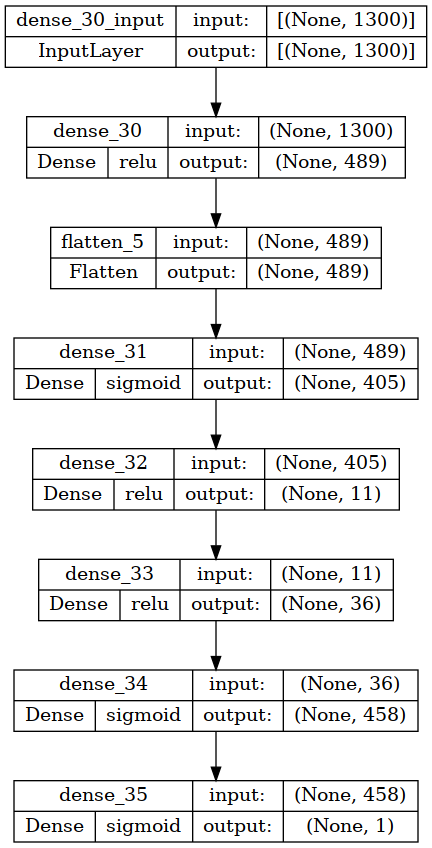

In [3]:
from tensorflow.keras.utils import plot_model
from tensorflow.keras.metrics import F1Score
import tensorflow as tf

model_for_testing = 'esm_new'
model = tf.keras.models.load_model('/home/dimitra/master_thesis/models/best_model_esm_new')

plot_model(
    model,
    to_file='model_plot.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=96,
    show_layer_activations=True,
)